# Ch.00 Overview — Microstructure Noise / TSRV

Pass 2.6 signal board for desk readers. Empirics live in sibling chapter notebooks; this page is the map.


In [1]:
from pathlib import Path
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # research/

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_ratio_hist.png', 'fig_tob_coverage.png', 'fig_tsrv_oos.png', 'signal_board.png']


## Signal board


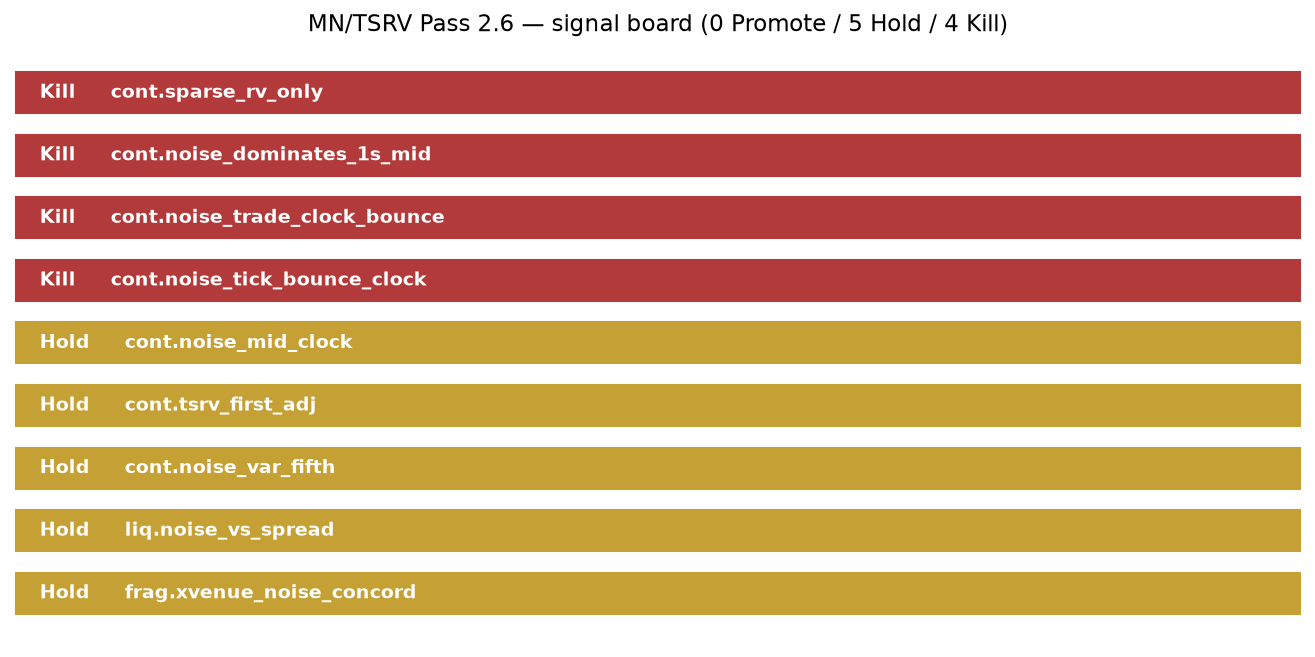

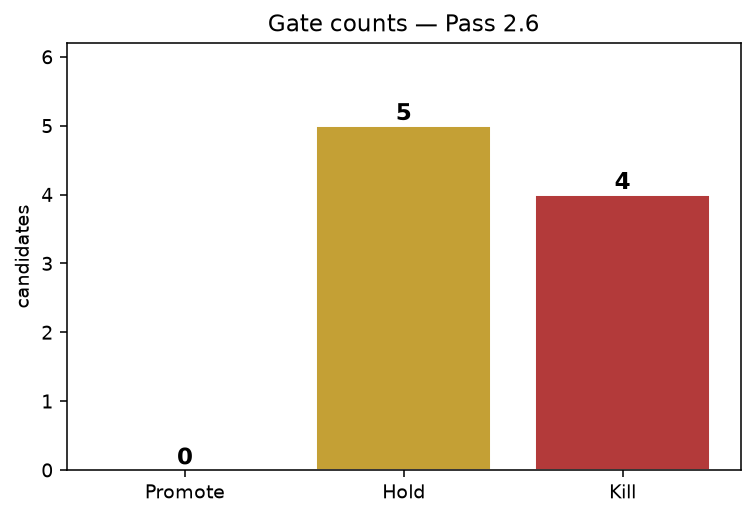

# Desk memo — Microstructure Noise / TSRV (Romero 2016 · ZMA05)

**Audience:** crypto MM / SOR / execution / taker / risk / research  
**Source:** Romero MA thesis (2016) / ZMA05 TSRV → `research/books/mn_tuwrv/`  
**Data:** warehouse trades + collector/warehouse TOB + Kraken spot L2 + futures REST ingest — **no ClickHouse MCP**  
**Program status:** **Pass 2.6 blocker-close** — **0 Promote** on mid-clock / tape TSRV; MC **Kill** sparse stands  
**SoT:** [`CHAPTER_INDEX.md`](CHAPTER_INDEX.md) · Lib: [`../../lib/tsrv.py`](../../lib/tsrv.py)  
**Artifacts:** [`out/blocker_close/`](out/blocker_close/) · [`out/gap_close/`](out/gap_close/) · [`out/kraken_futures_tob/`](out/kraken_futures_tob/)

---

## 1. TOB path diagnosis (Pass 2.6)

| Venue | Quoted TOB path | Status |
|-------|-----------------|--------|
| Hyperliquid | collector ∪ warehouse `l2_rebuild` | Dense |
| Deribit | warehouse `l2_snapshot_level` | Dense |
| Kraken **spot** | warehouse `l2_rebuild` via `spot\|BTC/USD` / `spot\|

In [2]:
show_fig('signal_board.png')
show_fig('fig_gate_counts.png')
print((BOOK/'DESK_MEMO.md').read_text()[:1800])


## Pre-registered gates


In [3]:
print(json.dumps(bc['meta'].get('gates'), indent=2))
print('blocker decisions:', json.dumps(bc['decisions'], indent=2)[:1500])


{
  "cont.noise_mid_clock": "CI_lo(fifth/fourth)>1.5",
  "cont.tsrv_first_adj": "fragile_rate=0 & sparse\u2212tsrv CI_lo>0 early\u2227late & n\u226520",
  "cont.sparse_rv_only": "Kill (MC; unchanged)"
}
blocker decisions: {
  "cont.noise_mid_clock": {
    "id": "cont.noise_mid_clock",
    "decision": "Hold",
    "why": "dense mid median=2.628 CI=[1.172,5.225] SE=0.971 n=73.0 (need CI_lo>1.5)"
  },
  "cont.tsrv_first_adj": {
    "id": "cont.tsrv_first_adj",
    "decision": "Hold",
    "why": "fragile_rate=0.011 adv_med=-2.75e-07 CI=[-2.306071822364372e-06, 1.1699299344884352e-06] SE=8.31e-07 earlyCI=[-4.654016190012627e-06, 1.3038927370727255e-05] lateCI=[-2.862172387962406e-06, 1.019566994153289e-06] ratio_med=1.0171 ratioCI=[0.9594350796515484, 1.0516421957379292] roll_ci_lo_pos_frac=0.00 n=90 (MC Kill sparse still stands; Promote needs OOS CI_lo>0 early\u2227late)"
  },
  "cont.sparse_rv_only": {
    "decision": "Kill",
    "why": "MC first_adj RMSE \u226a fourth; unchanged"
  }
}
